In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# sns.set_theme(style="whitegrid")
sns.set_palette("magma")

In [3]:
df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/course/datasets/df_full_last_version_1.csv')
df = df.dropna()
columns_ex = ['close', 'high', 'low', 'timestamp', ]

df_cl = df.drop(columns=columns_ex)

train_size = int(len(df_cl) * 0.8)
df_train = df_cl.iloc[:train_size].copy()
window = 4
df_test = df_cl.iloc[train_size + window:].copy()

In [4]:
X_train = df_train.drop(['target'], axis=1)
y_train = df_train['target']

X_test = df_test.drop(['target'], axis=1)
y_test = df_test['target']

In [5]:
model = RandomForestClassifier(n_estimators=100,
                               min_samples_leaf=5, # Ограничиваем переобучение
                               n_jobs=-1,
                               random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=5, n_jobs=-1, random_state=42)

In [6]:
y_probs = model.predict_proba(X_test)

уверенность модели в каждом из классов

In [7]:
y_probs

array([[0.21966243, 0.50775941, 0.27257816],
       [0.24285128, 0.54675753, 0.21039119],
       [0.226061  , 0.60210797, 0.17183103],
       ...,
       [0.30841275, 0.47821949, 0.21336776],
       [0.2818812 , 0.46159798, 0.25652081],
       [0.37436344, 0.4089376 , 0.21669896]])

In [8]:
y_final_pred = []
threshold = 0.52

for lst in y_probs:

    indx = np.argmax(lst)
    # не берем в учет флэт
    if lst[indx] > threshold and indx != 1:
        y_final_pred.append(indx - 1)
    else:
        y_final_pred.append(2)

In [9]:
y_final_pred = np.array(y_final_pred)

# Фильтруем и считаем метрики
mask = y_final_pred != 2
if mask.sum() > 0:
    acc = accuracy_score(y_test[mask], y_final_pred[mask])
    print(f"\n=== РЕЗУЛЬТАТЫ СТРАТЕГИИ (Порог {threshold}) ===")
    print(f"Совершено сделок: {mask.sum()} из {len(y_test)} (Coverage: {mask.sum()/len(y_test)*100:.2f}%)")
    print(f"Точность (Win Rate): {acc:.4f}")
    print("\n", classification_report(y_test[mask], y_final_pred[mask]))
else:
    print("Модель не сделала ни одной ставки. Снизь порог уверенности.")


=== РЕЗУЛЬТАТЫ СТРАТЕГИИ (Порог 0.52) ===
Совершено сделок: 19 из 3723 (Coverage: 0.51%)
Точность (Win Rate): 0.5263

               precision    recall  f1-score   support

        -1.0       0.50      0.83      0.62         6
         0.0       0.00      0.00      0.00         8
         1.0       0.56      1.00      0.71         5

    accuracy                           0.53        19
   macro avg       0.35      0.61      0.45        19
weighted avg       0.30      0.53      0.39        19



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Важность каждого отдельного признака

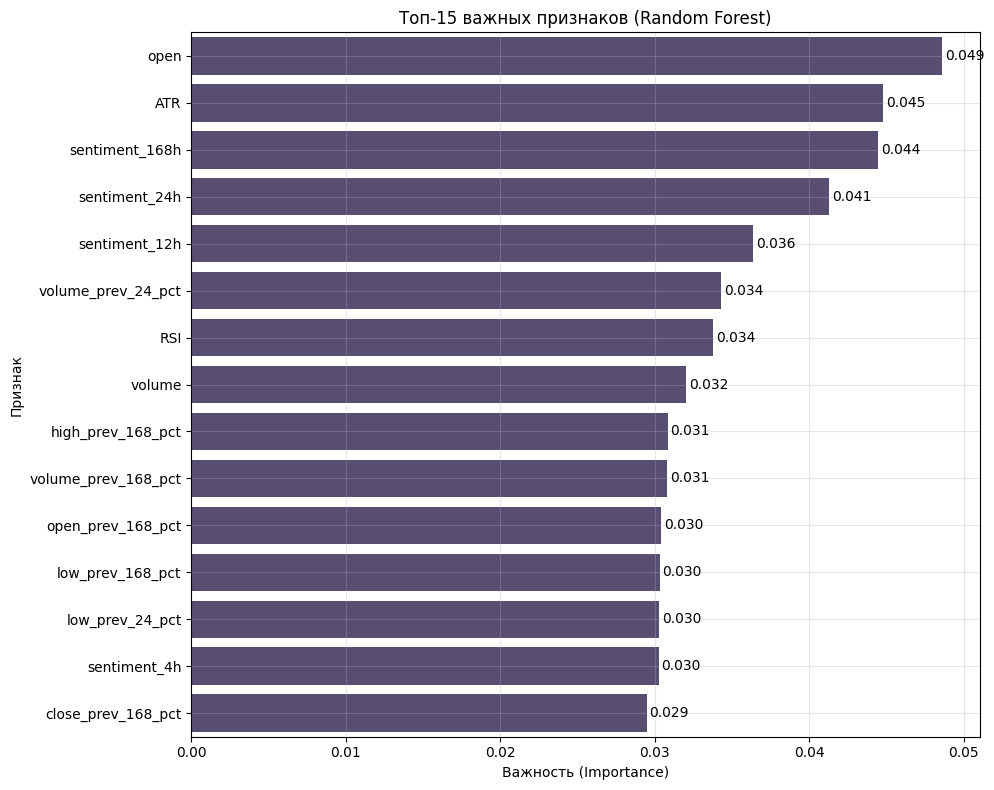

                Feature  Importance
0                  open    0.048615
32                  ATR    0.044781
31       sentiment_168h    0.044471
30        sentiment_24h    0.041292
29        sentiment_12h    0.036368
21   volume_prev_24_pct    0.034287
33                  RSI    0.033765
1                volume    0.032031
23    high_prev_168_pct    0.030832
26  volume_prev_168_pct    0.030805
22    open_prev_168_pct    0.030398
24     low_prev_168_pct    0.030319
19      low_prev_24_pct    0.030276
28         sentiment_4h    0.030252
25   close_prev_168_pct    0.029460


In [10]:
# Feature Importance
show_fetures = 15

importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(show_fetures), alpha=0.77)
plt.title('Топ-15 важных признаков (Random Forest)')
plt.xlabel('Важность (Importance)')
plt.ylabel('Признак')
plt.tight_layout()
plt.savefig('rf_feature_importance.png')

# Fix: Use ax.containers to get the bar container from the barplot
for container in ax.containers:
    plt.bar_label(container, padding=2, fmt='%.3f')

plt.grid(alpha=0.3)
plt.show()

print(feature_importance_df.head(show_fetures))

# Кривая доходности, BackTest

Запуск симуляции (Threshold: 0.52)...


100%|██████████| 3710/3710 [00:00<00:00, 253723.59it/s]


Финальный депозит: 1088.75$
Всего сделок: 19
Win Rate: 52.63%


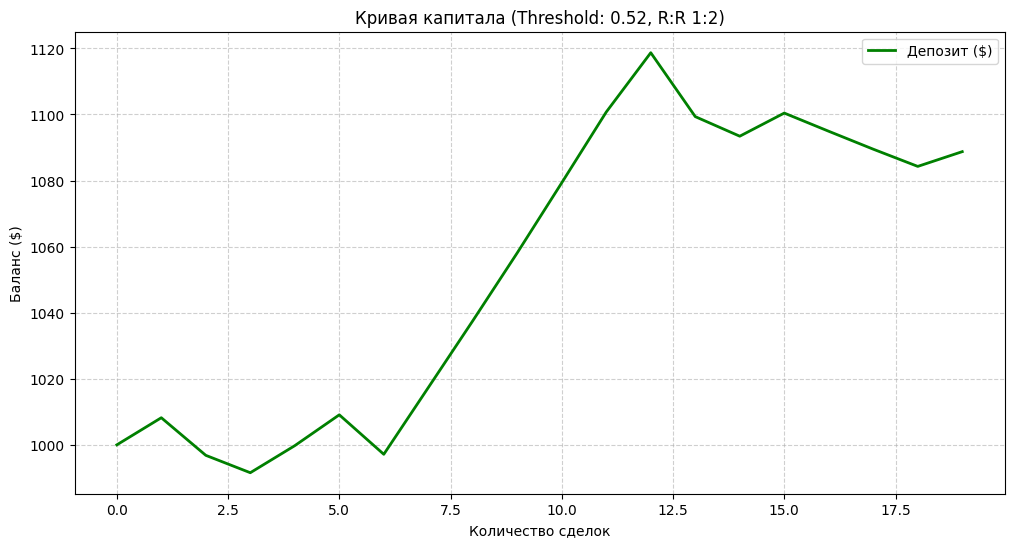

In [11]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# === НАСТРОЙКИ ===
threshold = 0.52  # Твой порог уверенности
equity = 1000     # Стартовый капитал
commission = 0.0006 # 0.06%
look_ahead = 12   # Горизонт прогноза

# Сюда будем сохранять историю изменения баланса для графика
equity_history = [equity]
history = []

# Берем индексы из теста
test_indices = df_test.index

print(f"Запуск симуляции (Threshold: {threshold})...")

# 1. Предсказания делаем ОДИН раз до цикла
all_probs = model.predict_proba(X_test)

for i in tqdm(range(len(test_indices) - look_ahead - 1)):
    idx = test_indices[i]

    # Берем вероятности
    probs = all_probs[i]

    # Логика классов: индекс 0 -> -1 (Short), индекс 2 -> 1 (Long)
    predicted_idx = np.argmax(probs)
    confidence = probs[predicted_idx]

    prediction = 0
    if predicted_idx == 0: prediction = -1
    elif predicted_idx == 2: prediction = 1

    # Фильтр
    if confidence < threshold or prediction == 0:
        continue

    # 2. Данные для сделки
    entry_price = df.loc[idx, 'close']
    atr = df.loc[idx, 'ATR']

    # Risk/Reward 1:2
    tp_dist = 2 * atr
    sl_dist = atr

    tp_price = entry_price + tp_dist if prediction == 1 else entry_price - tp_dist
    sl_price = entry_price - sl_dist if prediction == 1 else entry_price + sl_dist

    # 3. Проход в будущее
    outcome = 0
    for future_i in range(1, look_ahead + 1):
        future_idx = test_indices[i + future_i]
        curr_high = df.loc[future_idx, 'high']
        curr_low = df.loc[future_idx, 'low']

        if prediction == 1: # ЛОНГ
            if curr_low <= sl_price:
                outcome = -1
                break
            if curr_high >= tp_price:
                outcome = 1
                break
        elif prediction == -1: # ШОРТ
            if curr_high >= sl_price:
                outcome = -1
                break
            if curr_low <= tp_price:
                outcome = 1
                break

    # 4. Расчет PnL и обновление графика
    pnl = 0
    if outcome == 1:
        pnl = (abs(tp_price - entry_price) / entry_price) - (2 * commission)
        equity *= (1 + pnl)
        history.append('WIN')
    elif outcome == -1:
        pnl = (abs(entry_price - sl_price) / entry_price) + (2 * commission)
        equity *= (1 - pnl) # Вычитаем убыток
        history.append('LOSS')
    else:
        # Time Exit
        exit_idx = test_indices[i + look_ahead]
        close_price = df.loc[exit_idx, 'close']
        raw_pnl = (close_price - entry_price) / entry_price
        if prediction == -1: raw_pnl = -raw_pnl

        pnl = raw_pnl - (2 * commission)
        equity *= (1 + pnl)
        history.append('TIME_EXIT')

    equity_history.append(equity)

print(f"\nФинальный депозит: {equity:.2f}$")
print(f"Всего сделок: {len(history)}")
if len(history) > 0:
    win_rate = history.count('WIN') / len(history) * 100
    print(f"Win Rate: {win_rate:.2f}%")
else:
    print("Нет сделок")

plt.figure(figsize=(12, 6))
plt.plot(equity_history, label='Депозит ($)', color='green', linewidth=2)
plt.title(f'Кривая капитала (Threshold: {threshold}, R:R 1:2)')
plt.xlabel('Количество сделок')
plt.ylabel('Баланс ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [12]:
from google.colab import files

# 1. Создаем простую таблицу
# equity_history - это список, который мы заполнили в прошлом шаге
df_export = pd.DataFrame({
    'Trade': range(len(equity_history)), # Номер сделки (0, 1, 2...)
    'Balance': equity_history            # Твой депозит
})

# 2. Сохраняем в файл CSV (без индекса, чтобы Canva не запуталась)
filename = 'my_strategy_results.csv'
df_export.to_csv(filename, index=False)

print(f"Файл {filename} создан. Скачивание начнется автоматически...")

# 3. Скачиваем файл на твой компьютер
files.download(filename)

Файл my_strategy_results.csv создан. Скачивание начнется автоматически...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# 1. Достаем данные из модели
# model - это твой обученный Random Forest
# X_train - это таблица, на которой он учился (нужна для названий колонок)
importances = model.feature_importances_
feature_names = X_train.columns

# 2. Создаем красивую табличку
df_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

df_features_sorted = df_features.sort_values(by='Importance', ascending=False).head(7)

# 4. Сохраняем в CSV для Canva
filename_features = 'feature_importance_top15.csv'
df_features_sorted.to_csv(filename_features, index=False)

# 5. Скачиваем
files.download(filename_features)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>